USN NO- CS24D007
Vaishnavi Sandokar
 Extra Dataset Codes Based On practical 2 LINEAR REGRESSION

Saving insurance[1].csv to insurance[1].csv
['.config', 'insurance[1].csv', 'sample_data']
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


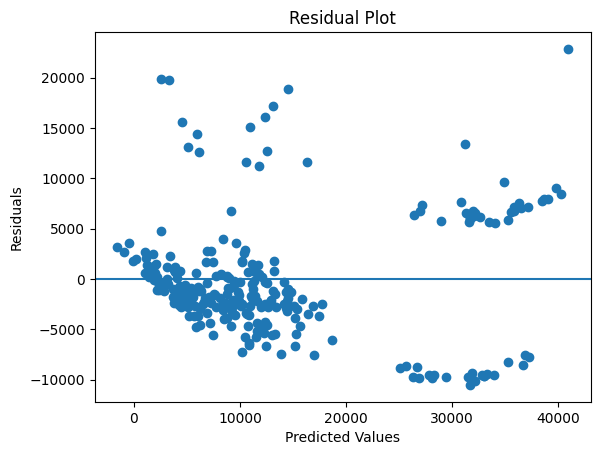

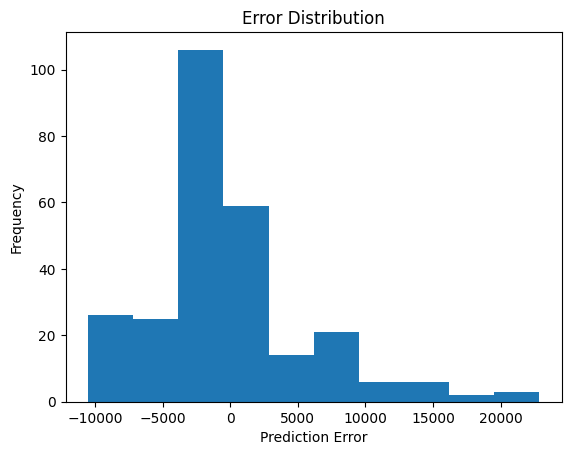

Predicted Insurance Charge: [25197.53106142]


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from google.colab import files
files.upload()

import os
print(os.listdir())
data = pd.read_csv("insurance[1].csv")

data = pd.read_csv("insurance[1].csv")
print(data.head())

print(data.info())
print(data.describe())

print(data.isnull().sum())

data_encoded = pd.get_dummies(data, drop_first=True)
print(data_encoded.head())

X = data_encoded.drop("charges", axis=1)
y = data_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
print(comparison.head())

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

print("Intercept:", model.intercept_)

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.hist(residuals)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()

new_data = X.iloc[:1]
prediction = model.predict(new_data)

print("Predicted Insurance Charge:", prediction)
